In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [13]:
# define state
class BMIState(TypedDict):
    height: float  # in meters
    weight: float  # in kilograms
    bmi: float     # body mass index
    label: str  # BMI category label

In [14]:
def calculate_bmi(state: BMIState) -> BMIState:
    height = state['height']
    weight = state['weight']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi, 2)
    return state

In [15]:
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        label = 'Underweight'
    elif 18.5 <= bmi < 24.9:
        label = 'Normal weight'
    elif 25 <= bmi < 29.9:
        label = 'Overweight'
    else:
        label = 'Obesity'
    state['label'] = label
    return state

In [16]:
# define your graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile your graph
workflow = graph.compile()

In [17]:
# execute your graph
initial_state = {
    'height': 1.73,
    'weight': 80.0
}

final_state = workflow.invoke(initial_state)

print(final_state)

{'height': 1.73, 'weight': 80.0, 'bmi': 26.73, 'label': 'Overweight'}


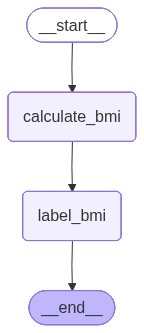

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())